In [18]:
%pip install torch torchvision Pillow matplotlib numpy jupyter kaggle


Note: you may need to restart the kernel to use updated packages.


In [19]:
import os
import random
import subprocess
from collections import Counter, defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from PIL import Image
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, models, transforms
from torchvision.models import MobileNet_V2_Weights


In [20]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

PROJECT_DIR = Path.cwd()
DATA_DIR = PROJECT_DIR / "data"
RAW_DATA_DIR = DATA_DIR / "raw"
MODEL_DIR = PROJECT_DIR / "models"
CUSTOM_IMAGE_DIR = DATA_DIR / "custom_images"

RAW_DATA_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)
CUSTOM_IMAGE_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project folder: {PROJECT_DIR}")
print(f"Raw data folder: {RAW_DATA_DIR}")
print(f"Model folder: {MODEL_DIR}")
print(f"Custom image folder: {CUSTOM_IMAGE_DIR}")


Project folder: c:\Users\darsh\Documents\Codex\2026-04-27\crop-disease-detection-system-i-am
Raw data folder: c:\Users\darsh\Documents\Codex\2026-04-27\crop-disease-detection-system-i-am\data\raw
Model folder: c:\Users\darsh\Documents\Codex\2026-04-27\crop-disease-detection-system-i-am\models
Custom image folder: c:\Users\darsh\Documents\Codex\2026-04-27\crop-disease-detection-system-i-am\data\custom_images


In [21]:
DATASET_SLUG = "mohitsingh1804/plantvillage"

existing_files = list(RAW_DATA_DIR.rglob("*"))

if len(existing_files) == 0:
    print("Downloading PlantVillage from Kaggle...")
    subprocess.run(
        [
            "kaggle",
            "datasets",
            "download",
            "-d",
            DATASET_SLUG,
            "-p",
            str(RAW_DATA_DIR),
            "--unzip",
        ],
        check=True,
    )
    print("Download complete.")
else:
    print("data/raw is not empty, so the notebook will reuse the existing dataset files.")


data/raw is not empty, so the notebook will reuse the existing dataset files.


In [22]:
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

def count_image_class_dirs(folder: Path) -> tuple[int, int]:
    class_dir_count = 0
    image_count = 0

    for child in folder.iterdir():
        if child.is_dir():
            child_image_count = sum(
                1
                for file_path in child.iterdir()
                if file_path.is_file() and file_path.suffix.lower() in IMAGE_EXTENSIONS
            )
            if child_image_count > 0:
                class_dir_count += 1
                image_count += child_image_count

    return class_dir_count, image_count

def find_imagefolder_root(search_root: Path) -> Path:
    candidates = []

    for current_folder, child_dirs, _ in os.walk(search_root):
        current_path = Path(current_folder)
        relative_depth = len(current_path.relative_to(search_root).parts)

        if relative_depth > 5:
            child_dirs[:] = []
            continue

        class_dir_count, image_count = count_image_class_dirs(current_path)

        if class_dir_count >= 10:
            color_bonus = 1_000_000 if current_path.name.lower() == "color" else 0
            score = color_bonus + class_dir_count * 10_000 + image_count
            candidates.append((score, class_dir_count, image_count, current_path))

    if len(candidates) == 0:
        raise FileNotFoundError(
            "Could not find a folder with class subfolders. "
            "Unzip PlantVillage inside data/raw and run this cell again."
        )

    candidates.sort(reverse=True, key=lambda item: item[0])
    best_folder = candidates[0][3]

    print("Top ImageFolder candidates:")
    for _, class_dir_count, image_count, folder in candidates[:5]:
        print(f"- {folder} | class folders: {class_dir_count} | images: {image_count}")

    return best_folder

DATASET_ROOT = find_imagefolder_root(RAW_DATA_DIR)
print(f"\nUsing dataset root: {DATASET_ROOT}")


Top ImageFolder candidates:
- c:\Users\darsh\Documents\Codex\2026-04-27\crop-disease-detection-system-i-am\data\raw\PlantVillage\train | class folders: 38 | images: 43444
- c:\Users\darsh\Documents\Codex\2026-04-27\crop-disease-detection-system-i-am\data\raw\PlantVillage\val | class folders: 38 | images: 10861

Using dataset root: c:\Users\darsh\Documents\Codex\2026-04-27\crop-disease-detection-system-i-am\data\raw\PlantVillage\train


In [23]:
def make_imagefolder(root: Path, transform=None) -> datasets.ImageFolder:
    dataset = datasets.ImageFolder(root=str(root), transform=transform)

    background_name = "Background_without_leaves"
    if background_name in dataset.classes:
        keep_class_names = [name for name in dataset.classes if name != background_name]
        old_to_new = {
            dataset.class_to_idx[class_name]: new_index
            for new_index, class_name in enumerate(keep_class_names)
        }

        filtered_samples = []
        for image_path, old_target in dataset.samples:
            if old_target in old_to_new:
                filtered_samples.append((image_path, old_to_new[old_target]))

        dataset.classes = keep_class_names
        dataset.class_to_idx = {name: index for index, name in enumerate(keep_class_names)}
        dataset.samples = filtered_samples
        dataset.imgs = filtered_samples
        dataset.targets = [target for _, target in filtered_samples]

        print("Removed Background_without_leaves to keep the project at 38 classes.")

    return dataset

base_dataset = make_imagefolder(DATASET_ROOT, transform=None)
class_names = base_dataset.classes
num_classes = len(class_names)

print(f"Total images: {len(base_dataset)}")
print(f"Total classes: {num_classes}")
print("First five classes:", class_names[:5])

if num_classes != 38:
    print(f"Warning: expected 38 classes, but found {num_classes}. Check DATASET_ROOT if this looks wrong.")


Total images: 43444
Total classes: 38
First five classes: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy']


Class distribution:
Apple___Apple_scab                              504
Apple___Black_rot                               496
Apple___Cedar_apple_rust                        220
Apple___healthy                                1316
Blueberry___healthy                            1202
Cherry_(including_sour)___Powdery_mildew        842
Cherry_(including_sour)___healthy               684
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot   410
Corn_(maize)___Common_rust_                     953
Corn_(maize)___Northern_Leaf_Blight             788
Corn_(maize)___healthy                          929
Grape___Black_rot                               944
Grape___Esca_(Black_Measles)                   1107
Grape___Leaf_blight_(Isariopsis_Leaf_Spot)      861
Grape___healthy                                 339
Orange___Haunglongbing_(Citrus_greening)       4405
Peach___Bacterial_spot                         1838
Peach___healthy                                 288
Pepper,_bell___Bacterial_spot          

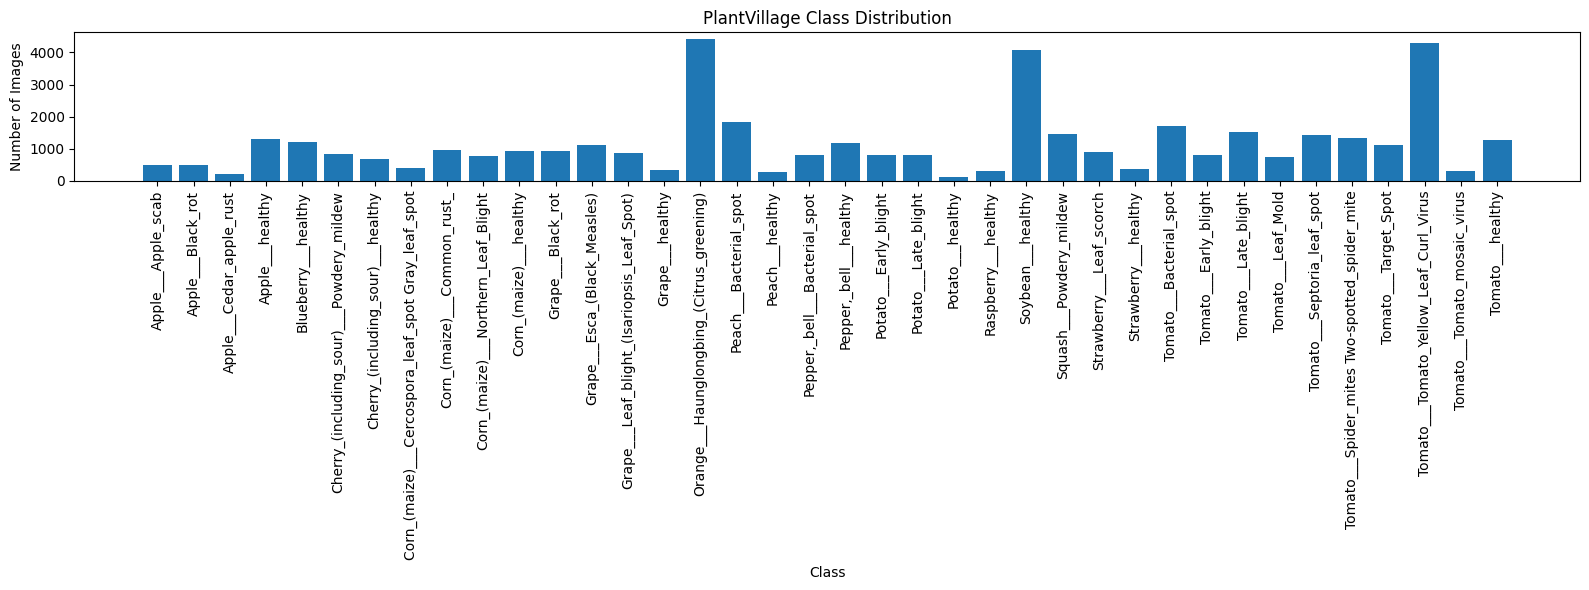

In [24]:
class_counts = Counter(base_dataset.targets)

print("Class distribution:")
for class_index, count in sorted(class_counts.items(), key=lambda item: class_names[item[0]]):
    print(f"{class_names[class_index]:45s} {count:5d}")

plt.figure(figsize=(16, 6))
plt.bar(class_names, [class_counts[index] for index in range(num_classes)])
plt.xticks(rotation=90)
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.title("PlantVillage Class Distribution")
plt.tight_layout()
plt.show()


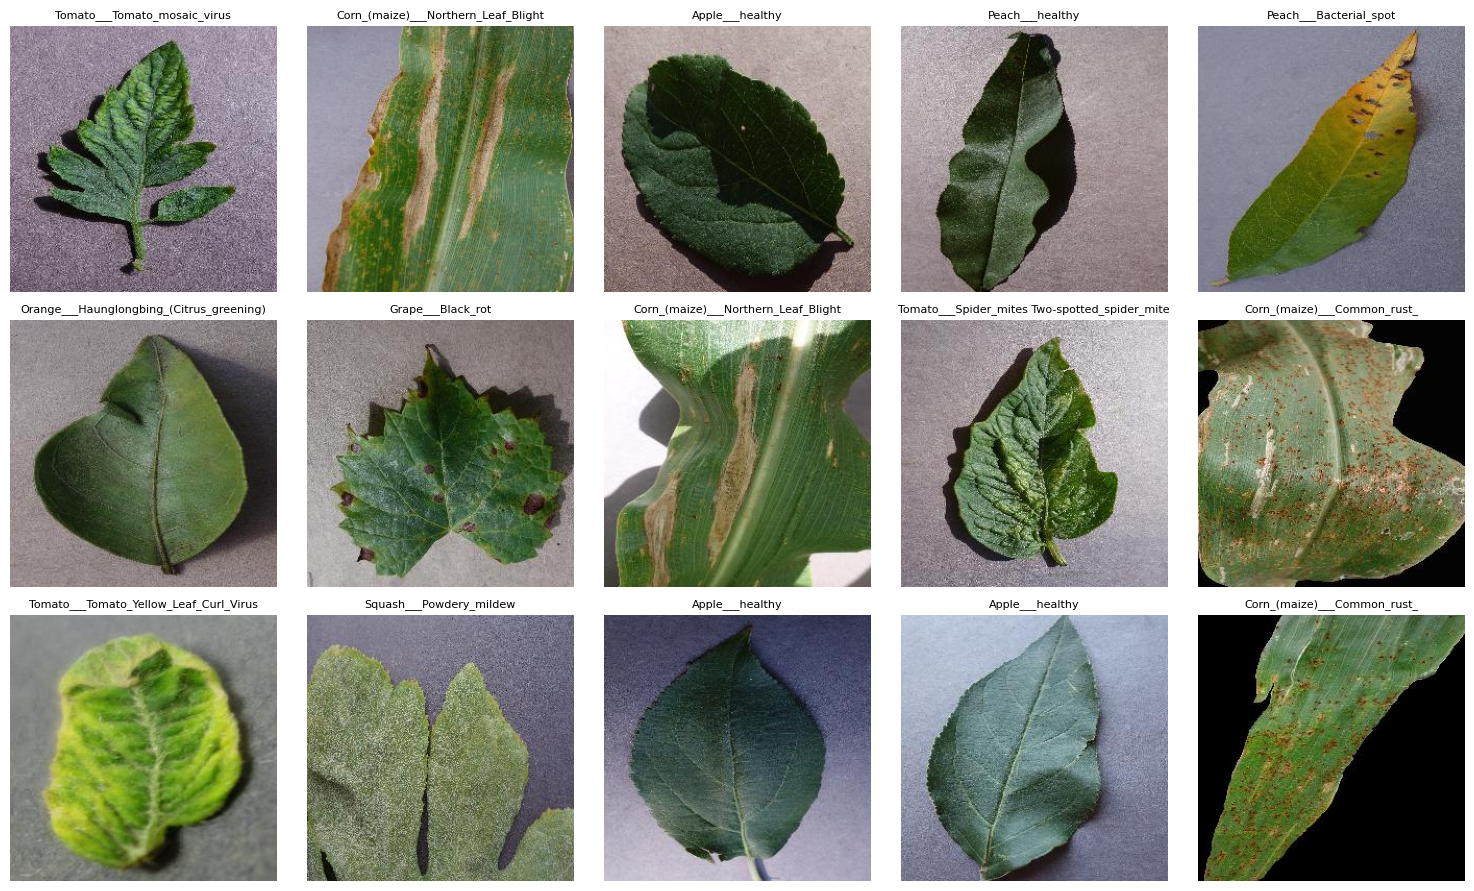

In [25]:
def show_sample_images(dataset, labels, rows=3, cols=5) -> None:
    sample_count = rows * cols
    sample_indices = random.sample(range(len(dataset)), sample_count)

    fig, axes = plt.subplots(rows, cols, figsize=(15, 9))
    axes = axes.ravel()

    for axis, dataset_index in zip(axes, sample_indices):
        image, label = dataset[dataset_index]
        axis.imshow(image)
        axis.set_title(labels[label], fontsize=8)
        axis.axis("off")

    plt.tight_layout()
    plt.show()

show_sample_images(base_dataset, class_names)


In [26]:
def stratified_split_indices(
    targets: list[int],
    train_ratio: float = 0.70,
    val_ratio: float = 0.15,
    seed: int = 42,
) -> tuple[list[int], list[int], list[int]]:
    label_to_indices = defaultdict(list)

    for dataset_index, label in enumerate(targets):
        label_to_indices[label].append(dataset_index)

    random_generator = random.Random(seed)
    train_indices = []
    val_indices = []
    test_indices = []

    for label, indices in label_to_indices.items():
        random_generator.shuffle(indices)

        total_count = len(indices)
        train_count = int(total_count * train_ratio)
        val_count = int(total_count * val_ratio)

        if total_count >= 3:
            train_count = max(1, train_count)
            val_count = max(1, val_count)
            if train_count + val_count >= total_count:
                train_count = total_count - 2
                val_count = 1

        train_indices.extend(indices[:train_count])
        val_indices.extend(indices[train_count : train_count + val_count])
        test_indices.extend(indices[train_count + val_count :])

    random_generator.shuffle(train_indices)
    random_generator.shuffle(val_indices)
    random_generator.shuffle(test_indices)

    return train_indices, val_indices, test_indices

train_indices, val_indices, test_indices = stratified_split_indices(base_dataset.targets, seed=SEED)

print(f"Training images:   {len(train_indices)}")
print(f"Validation images: {len(val_indices)}")
print(f"Test images:       {len(test_indices)}")


Training images:   30393
Validation images: 6501
Test images:       6550


In [27]:
IMAGE_SIZE = 224

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose(
    [
        transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.8, 1.0)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.2),
        transforms.RandomRotation(degrees=20),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ]
)

eval_transforms = transforms.Compose(
    [
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ]
)

train_full_dataset = make_imagefolder(DATASET_ROOT, transform=train_transforms)
eval_full_dataset = make_imagefolder(DATASET_ROOT, transform=eval_transforms)

train_dataset = Subset(train_full_dataset, train_indices)
val_dataset = Subset(eval_full_dataset, val_indices)
test_dataset = Subset(eval_full_dataset, test_indices)

print(f"Train dataset ready: {len(train_dataset)} images")
print(f"Validation dataset ready: {len(val_dataset)} images")
print(f"Test dataset ready: {len(test_dataset)} images")


Train dataset ready: 30393 images
Validation dataset ready: 6501 images
Test dataset ready: 6550 images


In [28]:
BATCH_SIZE = 32
NUM_WORKERS = 0

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PIN_MEMORY = device.type == "cuda"

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

print(f"Using device: {device}")


Using device: cpu


In [29]:
weights = MobileNet_V2_Weights.IMAGENET1K_V1
model = models.mobilenet_v2(weights=weights)

for parameter in model.features.parameters():
    parameter.requires_grad = False

input_features = model.classifier[1].in_features

model.classifier = nn.Sequential(
    nn.Dropout(p=0.2),
    nn.Linear(input_features, num_classes),
)

model = model.to(device)

print(model.classifier)


Sequential(
  (0): Dropout(p=0.2, inplace=False)
  (1): Linear(in_features=1280, out_features=38, bias=True)
)


In [30]:
EPOCHS = 3
LEARNING_RATE = 1e-3

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.classifier.parameters(), lr=LEARNING_RATE)

BEST_MODEL_PATH = MODEL_DIR / "mobilenetv2_plantvillage_best.pth"


In [31]:
def train_one_epoch(model, data_loader, criterion, optimizer, device) -> tuple[float, float]:
    model.train()

    running_loss = 0.0
    correct_predictions = 0
    total_images = 0

    for images, labels in data_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        batch_size = images.size(0)
        running_loss += loss.item() * batch_size

        predictions = outputs.argmax(dim=1)
        correct_predictions += (predictions == labels).sum().item()
        total_images += batch_size

    epoch_loss = running_loss / total_images
    epoch_accuracy = correct_predictions / total_images

    return epoch_loss, epoch_accuracy

def evaluate(model, data_loader, criterion, device) -> tuple[float, float]:
    model.eval()

    running_loss = 0.0
    correct_predictions = 0
    total_images = 0

    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            batch_size = images.size(0)
            running_loss += loss.item() * batch_size

            predictions = outputs.argmax(dim=1)
            correct_predictions += (predictions == labels).sum().item()
            total_images += batch_size

    epoch_loss = running_loss / total_images
    epoch_accuracy = correct_predictions / total_images

    return epoch_loss, epoch_accuracy


In [32]:
history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
}

best_val_accuracy = 0.0

for epoch in range(EPOCHS):
    train_loss, train_accuracy = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_accuracy = evaluate(model, val_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_accuracy)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_accuracy)

    print(
        f"Epoch [{epoch + 1}/{EPOCHS}] "
        f"Train Loss: {train_loss:.4f} "
        f"Train Acc: {train_accuracy:.4f} "
        f"Val Loss: {val_loss:.4f} "
        f"Val Acc: {val_accuracy:.4f}"
    )

    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy
        torch.save(
            {
                "model_state_dict": model.state_dict(),
                "class_names": class_names,
                "image_size": IMAGE_SIZE,
                "imagenet_mean": IMAGENET_MEAN,
                "imagenet_std": IMAGENET_STD,
                "best_val_accuracy": best_val_accuracy,
            },
            BEST_MODEL_PATH,
        )
        print(f"Saved new best model to {BEST_MODEL_PATH}")

print(f"Best validation accuracy: {best_val_accuracy:.4f}")


Epoch [1/3] Train Loss: 0.7106 Train Acc: 0.8162 Val Loss: 0.2519 Val Acc: 0.9274
Saved new best model to c:\Users\darsh\Documents\Codex\2026-04-27\crop-disease-detection-system-i-am\models\mobilenetv2_plantvillage_best.pth
Epoch [2/3] Train Loss: 0.3454 Train Acc: 0.8942 Val Loss: 0.1932 Val Acc: 0.9405
Saved new best model to c:\Users\darsh\Documents\Codex\2026-04-27\crop-disease-detection-system-i-am\models\mobilenetv2_plantvillage_best.pth
Epoch [3/3] Train Loss: 0.2962 Train Acc: 0.9057 Val Loss: 0.1889 Val Acc: 0.9360
Best validation accuracy: 0.9405


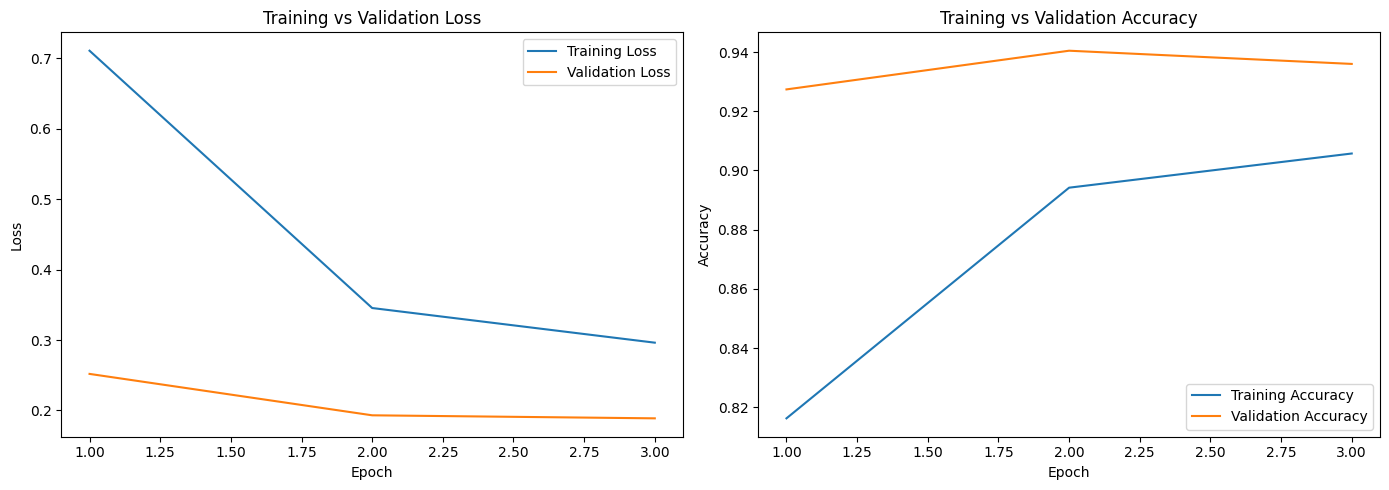

In [33]:
epochs_range = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, history["train_loss"], label="Training Loss")
plt.plot(epochs_range, history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, history["train_acc"], label="Training Accuracy")
plt.plot(epochs_range, history["val_acc"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

plt.tight_layout()
plt.show()


In [34]:
checkpoint = torch.load(BEST_MODEL_PATH, map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

test_loss, test_accuracy = evaluate(model, test_loader, criterion, device)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")


Test Loss: 0.1963
Test Accuracy: 0.9395


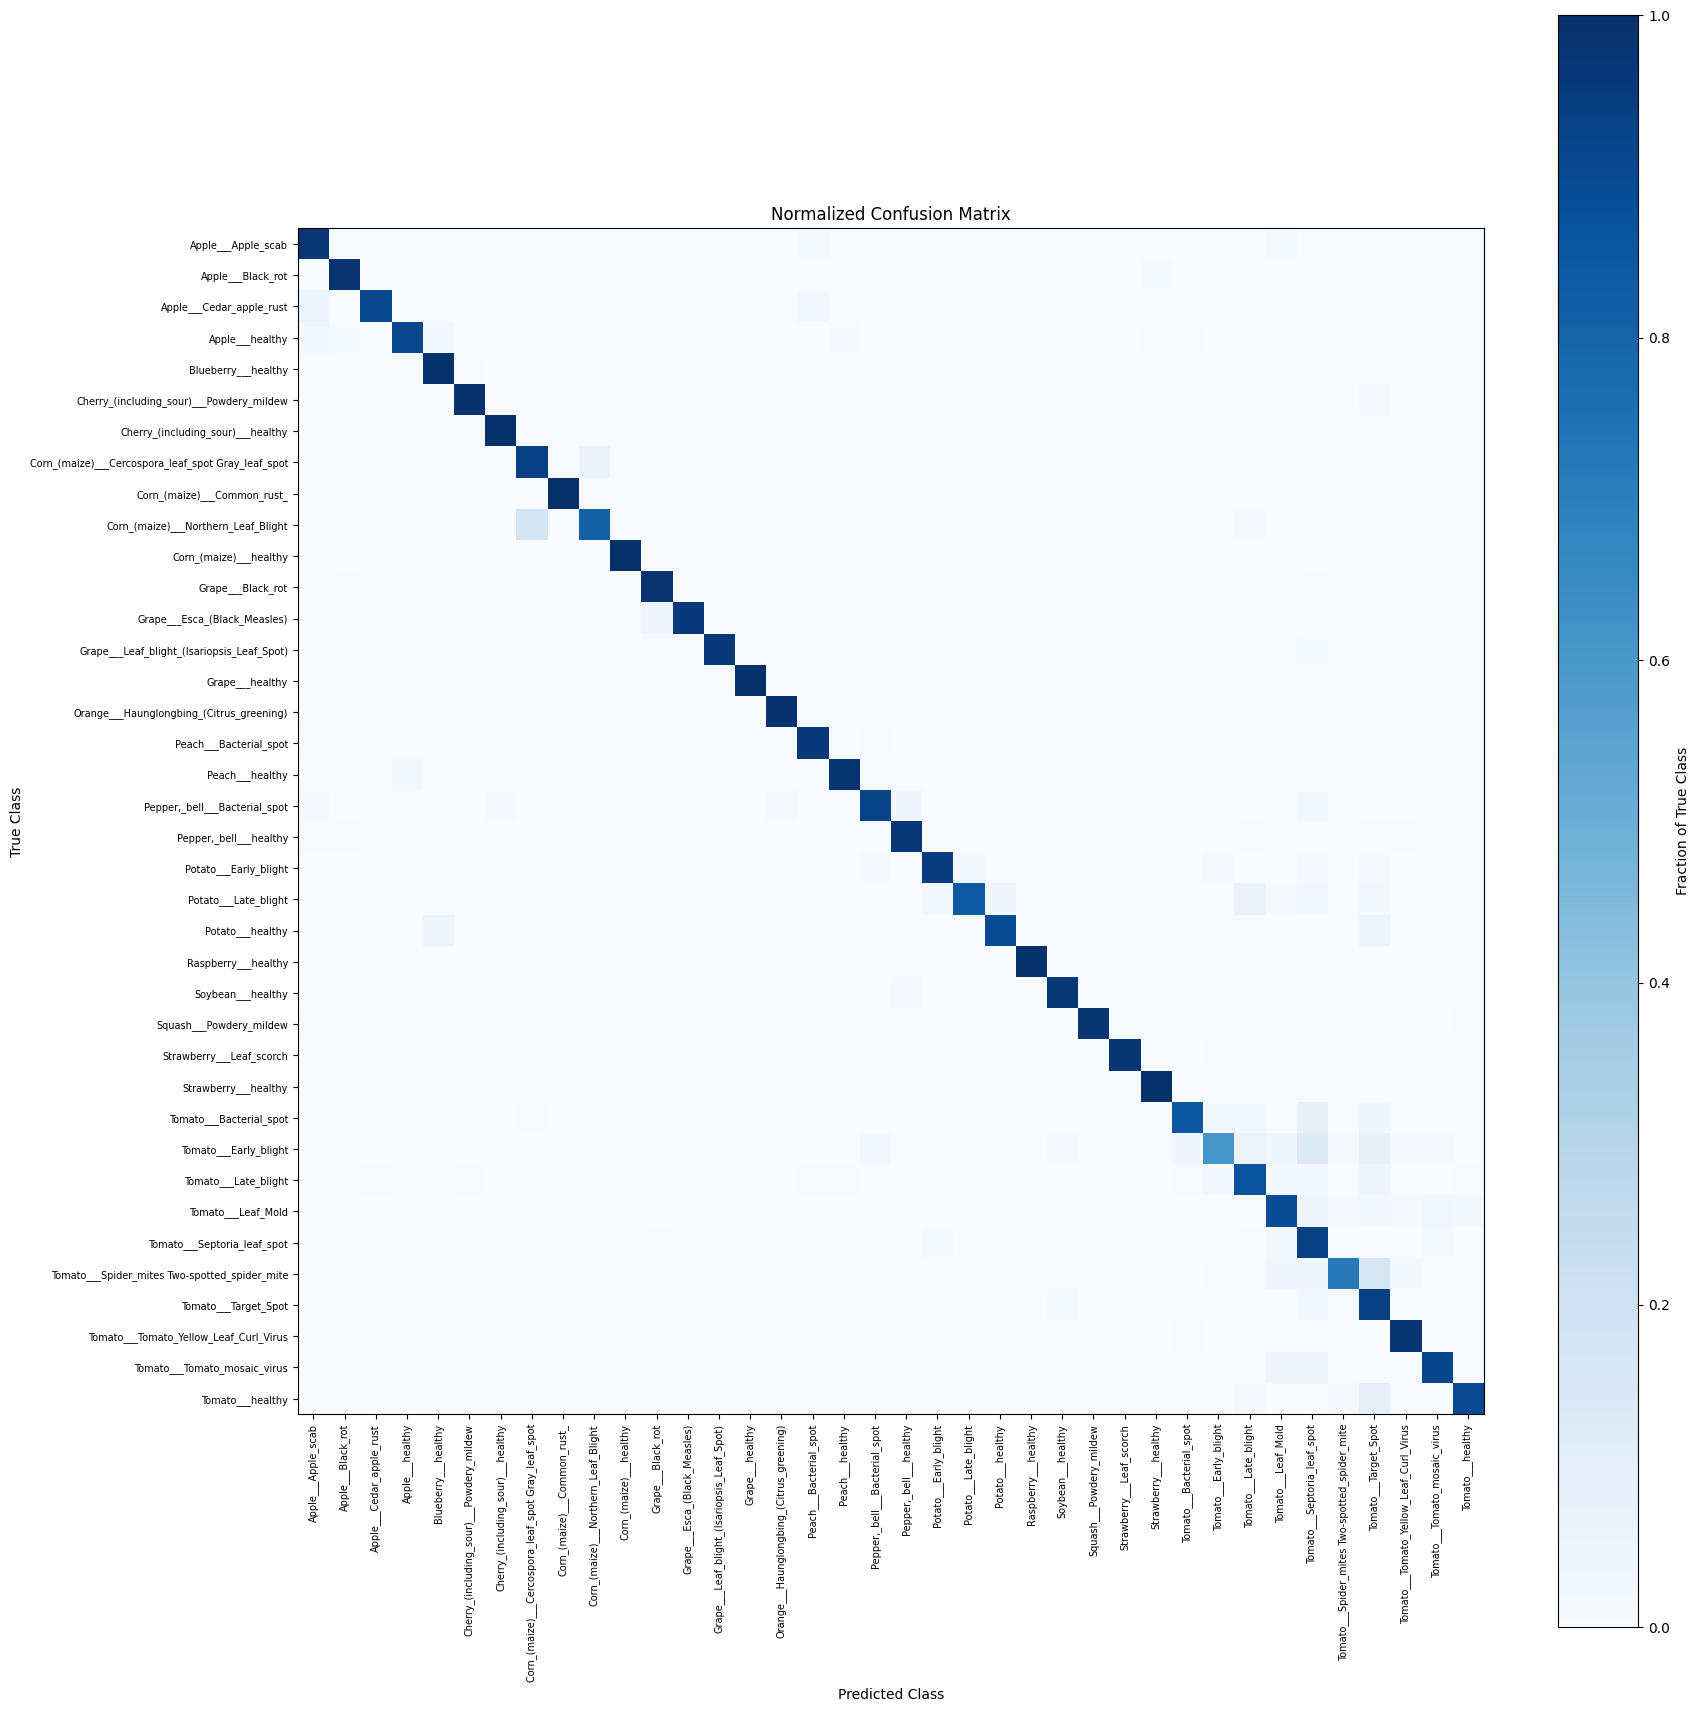

In [35]:
def collect_predictions(model, data_loader, device) -> tuple[torch.Tensor, torch.Tensor]:
    model.eval()

    all_predictions = []
    all_labels = []

    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)
            outputs = model(images)
            predictions = outputs.argmax(dim=1).cpu()

            all_predictions.append(predictions)
            all_labels.append(labels.cpu())

    return torch.cat(all_predictions), torch.cat(all_labels)

test_predictions, test_labels = collect_predictions(model, test_loader, device)

confusion_matrix = torch.zeros(num_classes, num_classes, dtype=torch.int64)

for true_label, predicted_label in zip(test_labels, test_predictions):
    confusion_matrix[true_label, predicted_label] += 1

normalized_confusion = confusion_matrix.float() / confusion_matrix.sum(dim=1, keepdim=True).clamp(min=1)

plt.figure(figsize=(18, 18))
plt.imshow(normalized_confusion.numpy(), cmap="Blues")
plt.colorbar(label="Fraction of True Class")
plt.xticks(range(num_classes), class_names, rotation=90, fontsize=7)
plt.yticks(range(num_classes), class_names, fontsize=7)
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title("Normalized Confusion Matrix")
plt.tight_layout()
plt.show()


In [36]:
correct_per_class = confusion_matrix.diag()
total_per_class = confusion_matrix.sum(dim=1).clamp(min=1)
per_class_accuracy = correct_per_class.float() / total_per_class

print("Per-class test accuracy:")
for class_index, accuracy in enumerate(per_class_accuracy):
    print(f"{class_names[class_index]:45s} {accuracy.item():.4f}")

worst_indices = torch.argsort(per_class_accuracy)[:5]
print("\nFive classes needing the most improvement:")
for class_index in worst_indices:
    print(f"{class_names[class_index]:45s} {per_class_accuracy[class_index].item():.4f}")


Per-class test accuracy:
Apple___Apple_scab                            0.9740
Apple___Black_rot                             0.9867
Apple___Cedar_apple_rust                      0.9091
Apple___healthy                               0.9091
Blueberry___healthy                           0.9890
Cherry_(including_sour)___Powdery_mildew      0.9921
Cherry_(including_sour)___healthy             1.0000
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot 0.9355
Corn_(maize)___Common_rust_                   1.0000
Corn_(maize)___Northern_Leaf_Blight           0.8151
Corn_(maize)___healthy                        1.0000
Grape___Black_rot                             0.9860
Grape___Esca_(Black_Measles)                  0.9581
Grape___Leaf_blight_(Isariopsis_Leaf_Spot)    0.9615
Grape___healthy                               1.0000
Orange___Haunglongbing_(Citrus_greening)      0.9909
Peach___Bacterial_spot                        0.9639
Peach___healthy                               0.9773
Pepper,_bell___B

In [37]:
def predict_single_image(
    image_path: Path,
    model,
    class_names: list[str],
    transform,
    device,
    top_k: int = 3,
) -> list[tuple[str, float]]:
    image = Image.open(image_path).convert("RGB")
    image_tensor = transform(image).unsqueeze(0)
    image_tensor = image_tensor.to(device)

    model.eval()
    with torch.no_grad():
        logits = model(image_tensor)
        probabilities = torch.softmax(logits, dim=1)
        top_probabilities, top_indices = probabilities.topk(top_k, dim=1)

    results = []
    for probability, class_index in zip(top_probabilities[0], top_indices[0]):
        class_name = class_names[class_index.item()]
        confidence = probability.item()
        results.append((class_name, confidence))

    return results

CUSTOM_IMAGE_PATH = CUSTOM_IMAGE_DIR / "my_leaf.jpg"

if CUSTOM_IMAGE_PATH.exists():
    predictions = predict_single_image(
        CUSTOM_IMAGE_PATH,
        model,
        class_names,
        eval_transforms,
        device,
        top_k=3,
    )

    image = Image.open(CUSTOM_IMAGE_PATH).convert("RGB")
    plt.figure(figsize=(5, 5))
    plt.imshow(image)
    plt.axis("off")
    plt.title(f"Prediction: {predictions[0][0]}\nConfidence: {predictions[0][1] * 100:.2f}%")
    plt.show()

    print("Top predictions:")
    for class_name, confidence in predictions:
        print(f"{class_name:45s} {confidence * 100:.2f}%")
else:
    print(f"No custom image found at: {CUSTOM_IMAGE_PATH}")
    print("Place an image there or update CUSTOM_IMAGE_PATH, then run this cell again.")


No custom image found at: c:\Users\darsh\Documents\Codex\2026-04-27\crop-disease-detection-system-i-am\data\custom_images\my_leaf.jpg
Place an image there or update CUSTOM_IMAGE_PATH, then run this cell again.
